# Heart Disease Prediction using Machine Learning: A Comparative Study of Baseline and Neural Network Models with Emphasis on Overfitting and Regularization.

## Stage 1: Defining the Problem and Assembling a Dataset

### Defining the Problem

Before building any model, the first step is to clearly define what problem we are trying to solve. In our case, the central question is: Can we predict whether a patient has heart disease based on their clinical data?

This means:

Input data (X): 13 clinical and demographic attributes from the Cleveland Heart Disease dataset, such as age, sex, chest pain type, blood pressure, cholesterol, ECG results, and others.

Output data (y): A binary indicator of whether the patient has heart disease (0 = no, 1 = yes).

It is important to recognize that we are making two hypotheses here:

That the input features actually contain enough information to determine the likelihood of heart disease.

That the data we have is representative enough to train a model that will generalize to unseen patients.

Until the models are trained and evaluated, these remain hypotheses to be tested.

### 1. Dataset Used

  The dataset used in this project is the Cleveland Heart Disease dataset (Kaggle version).
t contains 303 patient records, each annotated with 13 clinical and demographic attributes that are commonly used in medical diagnostics of cardiovascular health. These features include:

Age: Patient age in years.

Sex: Biological sex (1 = male, 0 = female).

Chest Pain Type (cp): Categorical variable describing four types of angina.

Resting Blood Pressure (trestbps): Measured in mm Hg at admission.

Serum Cholesterol (chol): Serum cholesterol level in mg/dl.

Fasting Blood Sugar (fbs): Binary indicator (1 if >120 mg/dl, 0 otherwise).

Resting Electrocardiographic Results (restecg): Categorized outcomes of resting ECG tests.

Maximum Heart Rate Achieved (thalach): Peak heart rate achieved during exercise.

Exercise-Induced Angina (exang): Binary indicator of chest pain induced by exercise.

ST Depression (oldpeak): ST depression induced by exercise relative to rest.

Slope of Peak Exercise ST Segment (slope): Categorical measure of slope.

Number of Major Vessels Colored by Fluoroscopy (ca): Integer ranging from 0 to 3.

Thalassemia (thal): Categorical indicator of thalassemia.

The target variable (target) represents the presence or absence of heart disease, encoded as:

0 - No heart disease

1 - Heart disease

This dataset is well known in the machine learning community as a benchmark for binary classification problems in the healthcare domain.

### 2. Problem Type

This is a binary classification problem. We are not trying to predict a continuous number (regression) or multiple categories (multiclass classification). Instead, we are simply trying to assign each patient into one of two categories:

“No heart disease”

“Heart disease”

This categorization matters because the type of problem directly influences the choice of model architectures, the loss function (binary cross-entropy in the case of neural networks), and the evaluation metrics (Balanced Accuracy, Precision, Recall, etc.).

### 3. Aims and Objectives

**Build Baseline Models and Compare Them with Neural Networks**

The first objective is to establish simple baseline models that serve as performance reference points. Classical algorithms such as Logistic Regression and Decision Trees are ideal for this role because they are easy to interpret, quick to train, and provide a transparent measure of what can be achieved with minimal complexity.

Once these baselines are in place, the project moves toward more advanced approaches such as Multi-Layer Perceptrons (MLPs). Neural networks can capture complex, nonlinear interactions that may be missed by simpler models. However, with the small dataset size, there is a genuine risk of overfitting. By comparing classical models to neural networks, we can evaluate whether the increased complexity actually leads to meaningful improvements in prediction accuracy.

**Evaluate Models Using Advanced Performance Metrics**

Accuracy alone does not always tell the full story, especially in healthcare datasets where one class may dominate (for example, more patients without heart disease than with it). Therefore, the second objective is to assess models using a comprehensive set of metrics that reveal different aspects of performance:

Balanced Accuracy ensures that both classes are treated fairly, even when the dataset is imbalanced.

Precision and Recall provide insight into the types of errors made. In this context, a false negative (missing a patient with heart disease) is far more serious than a false positive.

F1 Score balances Precision and Recall into a single measure that is especially useful when both false positives and false negatives matter.

ROC-AUC and PR-AUC evaluate the ability of the model to separate classes across thresholds, offering a global view of performance.

By combining these metrics, we avoid over-reliance on accuracy and instead develop a balanced evaluation framework that is more aligned with the critical needs of medical prediction.

**Show the Effects of Overfitting and How Regularization Can Improve Performance**

The third objective is not only to build strong models but also to understand their limitations. Neural networks, when applied to small datasets, are especially prone to overfitting—memorizing the training data rather than learning patterns that generalize.

This project will:

Track training and validation accuracy/loss curves to visualize when overfitting occurs.

Introduce regularization techniques such as dropout, L2 penalties, and early stopping to reduce overfitting.

Compare model performance with and without regularization to demonstrate how these techniques improve generalization.

This objective is both practical and educational. It shows how models can fail if unchecked and highlights the importance of regularization in ensuring that predictions remain reliable when applied to unseen data.

### 4. Constraints

The project faces several practical challenges that shape the modeling strategy:

**Dataset Size**
With only 303 samples, the dataset is relatively small for machine learning. This increases the risk of models overfitting, especially complex models such as neural networks.

**Class Imbalance**
Heart disease datasets often have unequal distributions of “disease” vs “no disease” cases. This imbalance can bias classifiers toward predicting the majority class. Balanced Accuracy is therefore critical for evaluation.

**Feature Characteristics**
The dataset contains both numerical and categorical variables, requiring appropriate preprocessing (normalization, one-hot encoding) before modeling.

**Overfitting Risk**
Neural networks in particular are prone to memorizing training data rather than generalizing, making careful evaluation protocols (e.g., K-Fold Cross Validation) essential.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/processed_cleveland.csv')
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


## Stage 2: Choosing Measure of Success

Evaluating a machine learning model is not as simple as reporting its accuracy. Especially in sensitive applications like healthcare, where the cost of misclassification can be high, it is crucial to define appropriate metrics that capture different aspects of performance. The Cleveland Heart Disease dataset, like many medical datasets, exhibits class imbalance: there are typically more patients without disease than with disease. In such cases, traditional accuracy can be misleading. For this reason, we adopt a multi-metric evaluation strategy.

**Balanced Accuracy**

Balanced Accuracy is selected as the primary metric because it corrects for class imbalance by averaging the recall across classes.

Definition: Balanced Accuracy = (Recall for Class 0 + Recall for Class 1) ÷ 2.

Interpretation: This metric ensures that the model is not rewarded for simply predicting the majority class. For example, if 70% of patients have no heart disease, a model that always predicts “no disease” will achieve 70% accuracy but only 50% balanced accuracy.

Why it matters here: In heart disease detection, both false negatives (missing a sick patient) and false positives (wrongly diagnosing a healthy patient) are costly. Balanced Accuracy provides a fair view of how well the model handles both groups.

**Precision**

Precision measures the trustworthiness of positive predictions.

Definition: Precision = TP / (TP + FP), where TP = true positives and FP = false positives.

Interpretation: Precision answers the question, “When the model predicts that a patient has heart disease, how often is it correct?”

Why it matters here: High precision reduces unnecessary anxiety and medical interventions for patients wrongly classified as sick.

**Recall** (Sensitivity)

Recall measures the model’s ability to detect actual positives.

Definition: Recall = TP / (TP + FN), where FN = false negatives.

Interpretation: Recall answers the question, “Of all the patients who truly have heart disease, how many did the model correctly identify?”

Why it matters here: In medicine, recall (sensitivity) is often more important than precision because failing to identify a diseased patient (false negative) can have severe consequences.

**F1 Score**

The F1 score is the harmonic mean of Precision and Recall.

Definition: F1 = 2 × (Precision × Recall) / (Precision + Recall).

Interpretation: It balances the trade-off between Precision and Recall, especially when they are uneven.

Why it matters here: F1 is particularly useful in imbalanced datasets, where optimizing for one metric (like Precision) may reduce the other (Recall). F1 provides a single, balanced measure.

**ROC-AUC (Receiver Operating Characteristic – Area Under Curve)**

ROC-AUC summarizes the model’s performance across different classification thresholds.

Definition: Plots the True Positive Rate (Recall) against the False Positive Rate at various thresholds. AUC (Area Under the Curve) quantifies the overall separability.

Interpretation: ROC-AUC answers the question, “How well can the model distinguish between patients with and without heart disease?”

Why it matters here: A high AUC indicates that the model is robust across different decision thresholds, which is critical when clinical settings may demand different trade-offs between sensitivity and specificity.

**PR-AUC (Precision–Recall Area Under Curve)**

PR-AUC is particularly informative in highly imbalanced datasets.

Definition: Plots Precision vs. Recall at different thresholds, with the area under this curve providing a single summary score.

Interpretation: Unlike ROC-AUC, which can remain deceptively high under severe imbalance, PR-AUC focuses only on the performance for the positive class *patients with disease*.

Why it matters here: If the dataset were extremely skewed toward healthy patients, PR-AUC would give a more realistic picture of model utility in identifying the minority class *patients at risk*.

In [ ]:
# Example metrics import
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Stage 3: Choosing Evaluation Protocol

Since we have a small dataset, a simple train/test split may not be reliable. Instead, we use:

K-Fold Cross-Validation (preferred)

With a limited dataset, the evaluation method must make the best possible use of all available data. A single split into training and test sets can give misleading results because the model’s performance depends heavily on which records happen to be in the test set.

**K-Fold Cross-Validation** addresses this by:

* Splitting the dataset into **k equal folds** (here, k = 5).

* Training the model on **k–1 folds** while validating on the remaining fold.

* Repeating this process **k times**, each time with a different fold serving as the validation set.

* Averaging the performance across all folds to obtain a stable estimate.

This approach ensures that every data point is used for validation exactly once and for training in the remaining folds. As a result, it provides a fairer and more reliable assessment of model performance compared to a single split. It also helps reveal how consistently the model performs across different subsets of the data.

Alternative Options

While K-Fold Cross-Validation is the preferred method for small datasets, there are other strategies:

* Hold-out Validation:
The dataset is divided once into training and testing sets (e.g., 70/30 or 80/20). This method is straightforward and computationally cheaper, but it can waste valuable data when the dataset is small, and results can vary depending on the split.

* Iterated K-Fold:
This method repeats K-Fold Cross-Validation multiple times with different random partitions and averages the results. It produces an even more robust evaluation but at a higher computational cost.

Protocol Selected in This Project

For this project, I adopt **5-Fold Cross-Validation**. This choice provides a good balance between computational efficiency and reliability. Each model is trained and validated five times, ensuring that:

* Results are less dependent on a single random split of the dataset.

* Performance metrics reflect the true generalization ability of the models.

* Both classes (heart disease and no heart disease) remain represented across folds, which is important under class imbalance.

This protocol ensures that evaluation is both fair and statistically sound, making the most of the limited data while avoiding overly optimistic or pessimistic performance estimates.

In [ ]:
# 5-Fold Cross-Validation with Balanced Accuracy (Logistic Regression Example)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from sklearn.impute import SimpleImputer

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ba, prec, rec, f1, roc = [], [], [], [], []

# Convert y to a NumPy array for consistent indexing
y_np = y.to_numpy()

# Ensure X is a NumPy array
X_np = X.to_numpy()

# Impute missing values before cross-validation
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_np = imputer.fit_transform(X_np)


# Check the type of X before splitting
print(f"Type of X before splitting: {type(X_np)}")

for fold, (tr, va) in enumerate(skf.split(X_np, y_np), 1):
    model = LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1)
    # Use NumPy array indexing for both X_np and y_np
    model.fit(X_np[tr], y_np[tr])
    proba = model.predict_proba(X_np[va])[:, 1]
    pred  = (proba >= 0.5).astype(int)

    ba.append(balanced_accuracy_score(y_np[va], pred))
    prec.append(precision_score(y_np[va], pred))
    rec.append(recall_score(y_np[va], pred))
    f1.append(f1_score(y_np[va], pred))
    roc.append(roc_auc_score(y_np[va], proba))

print(f"Balanced Accuracy: {np.mean(ba):.3f} ± {np.std(ba):.3f}")
print(f"Precision        : {np.mean(prec):.3f} ± {np.std(prec):.3f}")
print(f"Recall           : {np.mean(rec):.3f} ± {np.std(rec):.3f}")
print(f"F1               : {np.mean(f1):.3f} ± {np.std(f1):.3f}")
print(f"ROC-AUC          : {np.mean(roc):.3f} ± {np.std(roc):.3f}")

Type of X before splitting: <class 'numpy.ndarray'>
Balanced Accuracy: 0.830 ± 0.035
Precision        : 0.826 ± 0.052
Recall           : 0.806 ± 0.063
F1               : 0.814 ± 0.039
ROC-AUC          : 0.907 ± 0.017


In [ ]:
# 5-Fold Cross-Validation with Balanced Accuracy (Keras MLP)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import numpy as np
from sklearn.impute import SimpleImputer
import pandas as pd

def build_mlp(input_dim):
    m = Sequential([
        Dense(32, activation='relu', input_dim=input_dim),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ba_scores = []

# Check if df is loaded, if not load it
try:
    df
except NameError:
    print("df not found. Loading dataset...")
    df = pd.read_csv('/content/processed_cleveland.csv')
    # Handle missing values represented by '?'
    df.replace('?', np.nan, inplace=True)

# Check if X and y are defined, if not, perform preprocessing
try:
    X, y
except NameError:
    print("X or y not found. Performing preprocessing...")
    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Remove the imputation and standardization outside the loop
# Impute missing values before standardization
# imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# X = imputer.fit_transform(X)

# Standardize
# scaler = StandardScaler()
# X = scaler.fit_transform(X)


for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    # Get train and validation data for the current fold
    Xtr_fold, ytr_fold = X.iloc[tr], y.iloc[tr]
    Xva_fold, yva_fold = X.iloc[va], y.iloc[va]

    # Impute missing values within the loop
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    Xtr_fold_imputed = imputer.fit_transform(Xtr_fold)
    Xva_fold_imputed = imputer.transform(Xva_fold)

    # Standardize data within the loop
    scaler = StandardScaler()
    Xtr_fold_scaled = scaler.fit_transform(Xtr_fold_imputed)
    Xva_fold_scaled = scaler.transform(Xva_fold_imputed)


    model = build_mlp(Xtr_fold_scaled.shape[1])

    model.fit(Xtr_fold_scaled, ytr_fold, epochs=50, batch_size=32, verbose=0)
    proba = model.predict(Xva_fold_scaled, verbose=0).ravel()
    pred  = (proba >= 0.5).astype(int)
    ba    = balanced_accuracy_score(yva_fold, pred)
    ba_scores.append(ba)
    print(f"Fold {fold} Balanced Accuracy: {ba:.3f}")

print(f"MLP 5-fold Balanced Accuracy: {np.mean(ba_scores):.3f} ± {np.std(ba_scores):.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Balanced Accuracy: 0.853


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Balanced Accuracy: 0.802


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Balanced Accuracy: 0.845


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Balanced Accuracy: 0.801


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Balanced Accuracy: 0.826
MLP 5-fold Balanced Accuracy: 0.825 ± 0.021


In [ ]:
#Check fold sizes
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, val_index in kf.split(df):
    print('Train:', len(train_index), 'Validation:', len(val_index))

Train: 242 Validation: 61
Train: 242 Validation: 61
Train: 242 Validation: 61
Train: 243 Validation: 60
Train: 243 Validation: 60


## Stage 4: Preparing the Data
1. Data Preprocessing

  Before training any models, it is essential to carefully prepare the dataset. Data preprocessing ensures that the inputs are consistent, clean, and suitable for machine learning algorithms. Given the small size of the Cleveland Heart Disease dataset, careful preprocessing is particularly important to avoid information loss and to maximize the signal available for the models.

a) Load and preview data

The first step involves loading the dataset into a working environment and examining its structure. We check the shape of the dataset (number of rows and columns), the names of the features, and the first few rows of data. This initial inspection helps us confirm that the dataset was loaded correctly and provides a first look at the values we will be working with.

b) Check missing values

Next, we identify whether the dataset contains missing or invalid entries. In some medical datasets, missing values are represented as blanks, NaN, or placeholder symbols such as ?. Detecting these is crucial because machine learning models cannot handle missing values directly.

c) Handle missing values

Once identified, missing values must be addressed. Two main strategies are considered:

Dropping records or features if the amount of missing data is very small and does not impact the dataset significantly.

Imputation, where missing values are replaced with meaningful substitutes, such as the mean, median, or mode of the feature.

For a small dataset like this, dropping too many rows is risky, as it reduces the already limited data available. Therefore, imputation is often the preferred strategy.

d) Standardize numeric features

Many features, such as cholesterol levels, blood pressure, and age, are measured on different scales. Standardization ensures that all numeric variables are transformed to have a mean of 0 and a standard deviation of 1. This step prevents features with larger numeric ranges from dominating the learning process. Algorithms like Logistic Regression, Neural Networks, and KNN in particular benefit from standardized inputs.

e) Encode categorical variables

Certain features, such as sex, chest pain type (cp), and thalassemia (thal), are categorical. Since most machine learning models operate on numerical data, these must be converted into numerical form. We use one-hot encoding, which creates binary columns for each category, ensuring that the encoded data does not imply any unintended ordinal relationships.

2. Explore Class Imbalance

Before splitting the data, it is necessary to analyze the distribution of the target variable. In medical datasets, it is common for one class (e.g., “no heart disease”) to be more frequent than the other (“heart disease”).

By checking the counts of the target values, we can confirm whether such imbalance exists. If there is significant imbalance, methods like class weighting during training can be applied. Class weights adjust the learning process so that errors made on the minority class are penalized more heavily, helping the model treat both classes fairly.

3. Split Data

Finally, the dataset is divided into training and validation subsets. For this stage, we use an 80/20 split:

* 80% of the data is used for training the models.

* 20% of the data is held out for validation, serving as an initial check on how well the model generalizes.

This split is a standard practice, but it is only a preliminary step. In the next stage, K-Fold Cross-Validation introduced earlier provides a more reliable evaluation protocol, ensuring that the limited dataset is used to its fullest potential.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


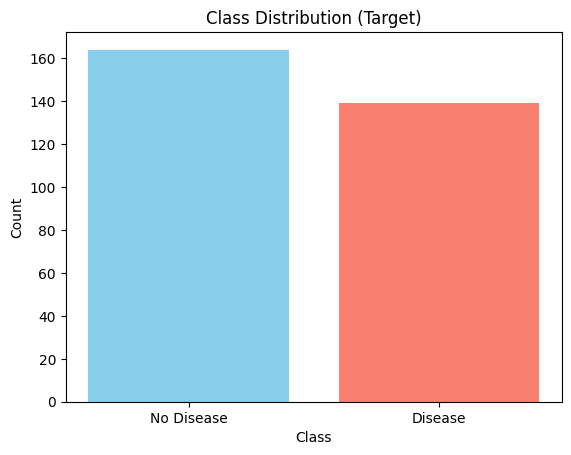

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Handle missing values represented by '?'
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

# Features and target
X = df.drop('num', axis=1)
# Convert multiclass target to binary (0: no disease, >0: disease)
y = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values before standardization
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)


# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_train.shape, X_val.shape

# Check class distribution
class_counts = y.value_counts()

plt.bar(class_counts.index, class_counts.values, color=['skyblue','salmon'])
plt.xticks([0,1], ['No Disease','Disease'])
plt.title("Class Distribution (Target)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

"Class Distribution (Target)," visually represents the number of instances for each class in your binary target variable, where 0 indicates no heart disease and 1 indicates heart disease. You can see two bars in the plot, corresponding to these two classes. The height of each bar directly indicates the count of patients in your dataset belonging to that specific class. In this particular dataset, the plot shows that there are approximately 164 patients in the "No Disease" class and around 139 patients in the "Disease" class. This difference in the number of samples between the classes highlights the presence of class imbalance, which is common in healthcare datasets. Understanding this imbalance is vital because training a model on such data without accounting for it can lead to a bias towards the majority class, resulting in poor performance in identifying the minority class, which is often the critical outcome in medical predictions. This is precisely why you are using evaluation metrics like Balanced Accuracy, Precision, and Recall, which provide a more comprehensive and fairer assessment of your model's performance, especially in the presence of class imbalance, by considering both false positives and false negatives.

## Stage 5: Baseline and Neural Models

After preparing the data and defining evaluation metrics, the next step is to train and compare different models. In this stage, we begin with simple, interpretable models to establish a baseline, and then move toward progressively more complex neural architectures. This structured approach ensures that any observed performance gain from advanced models is meaningful and not simply due to added complexity.

**Baseline Logistic Regression**:-

The first model is Logistic Regression, a linear classifier that is widely used in medical prediction tasks. Logistic Regression is:

- Interpretable: Coefficients directly indicate the influence of each clinical feature on the probability of heart disease. For example, a positive weight on “cholesterol” would suggest that higher cholesterol levels increase disease risk.

- Efficient: It is computationally inexpensive and suitable for small datasets.

- Benchmark Setting: The performance of Logistic Regression serves as the baseline, providing a reference point for evaluating whether more complex models are justified.

**Class Weights for Imbalance**:-

Medical datasets often suffer from class imbalance, where one class (e.g., patients without heart disease) is more frequent than the other (patients with heart disease). If unaddressed, models tend to bias toward the majority class, achieving high accuracy but poor sensitivity.

To counter this, we use class weights:

- Misclassifying a minority class sample (a patient with heart disease) is penalized more heavily.

- This ensures the model focuses on detecting both classes fairly.

- When combined with Balanced Accuracy as an evaluation metric, class weighting helps achieve a more equitable performance assessment.

**Neural Models**:-

Once the baseline is established, the project introduces neural networks, which are capable of modeling nonlinear and complex relationships among features. Two variants are considered:

a) **Single Layer Perceptron (SLP)**

The simplest neural model, consisting of:

- One hidden layer.

- A nonlinear activation function such as ReLU.

- A sigmoid output for binary classification.

The SLP provides a bridge between linear models like Logistic Regression and deeper networks, showing whether even a modest increase in model capacity yields improvements.

b) **Deep Neural Network (Multi-Layer Perceptron, MLP)**

The MLP introduces multiple hidden layers with ReLU activations. Its advantages include:

- Ability to capture nonlinear interactions between variables (e.g., the combined effect of cholesterol and age).

- Greater representational power compared to shallow models.

- Flexibility to tune depth, width, and regularization methods.

However, MLPs are also prone to overfitting, especially on small datasets, making careful monitoring of training essential.

**Training and Evaluation**

All models are trained on the processed dataset and evaluated using the metrics defined in Stage 2: Balanced Accuracy, Precision, Recall, F1 Score, ROC-AUC, and PR-AUC.

This systematic evaluation allows us to:

- Compare baselines with neural networks fairly.

- Assess not just raw accuracy but also the model’s ability to handle class imbalance.

- Quantify whether added complexity truly translates into better generalization.

**Performance Analysis and Visualization**

To better understand model behavior, we analyze results along two dimensions:

- **Metric Comparison Across Models**:
Performance is compared across Logistic Regression, SLP, and MLP. This helps highlight whether neural networks outperform simpler models or merely overfit.

- **Training Dynamics Visualization**:
For neural networks, we plot training and validation accuracy/loss curves over epochs. These visualizations reveal:

- - Whether the model converges smoothly or fluctuates.

- - Signs of overfitting, such as rising training accuracy while validation accuracy stagnates or decreases.

- - The effect of regularization techniques (e.g., dropout, early stopping) in controlling overfitting.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Baseline Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_baseline = logreg.predict(X_val)
print(classification_report(y_val, y_pred_baseline))

# Calculate and print ROC AUC
roc_auc_baseline = roc_auc_score(y_val, logreg.predict_proba(X_val)[:, 1])
print(f"ROC AUC: {roc_auc_baseline:.2f}")

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

ROC AUC: 0.92


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Check if df is loaded, if not load it
try:
    df
except NameError:
    print("df not found. Loading dataset...")
    df = pd.read_csv('/content/processed_cleveland.csv')
    # Handle missing values represented by '?'
    df.replace('?', np.nan, inplace=True)

# Check if X_train, y_train, X_val, y_val are defined, if not, perform train_test_split and preprocessing
try:
    X_train, X_val, y_train, y_val
except NameError:
    print("X_train, y_train, X_val, y_val not found. Performing train_test_split and preprocessing...")
    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Impute missing values before standardization
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

# Simple Neural Network (SLP)
model_slp = Sequential([
    Dense(1, input_dim=X_train.shape[1], activation='sigmoid')
])
model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_slp = model_slp.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val), verbose=1)

# Calculate and print Balanced Accuracy for SLP
y_pred_slp = (model_slp.predict(X_val) >= 0.5).astype(int)
balanced_acc_slp = balanced_accuracy_score(y_val, y_pred_slp)
print(f"\nSLP Balanced Accuracy on Validation Set: {balanced_acc_slp:.3f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6067 - loss: 0.7381 - val_accuracy: 0.7541 - val_loss: 0.5513
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6325 - loss: 0.6783 - val_accuracy: 0.7541 - val_loss: 0.5322
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6219 - loss: 0.6955 - val_accuracy: 0.7541 - val_loss: 0.5153
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6391 - loss: 0.6902 - val_accuracy: 0.7541 - val_loss: 0.4991
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6337 - loss: 0.6900 - val_accuracy: 0.7541 - val_loss: 0.4844
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6920 - loss: 0.6381 - val_accuracy: 0.7705 - val_loss: 0.4698
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6539 - loss: 0.6742 - val_accuracy: 0.7869 - val_loss: 0.4563
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6676 - loss: 0.6240 - val_accuracy: 0.7869 - val_loss: 0.4448

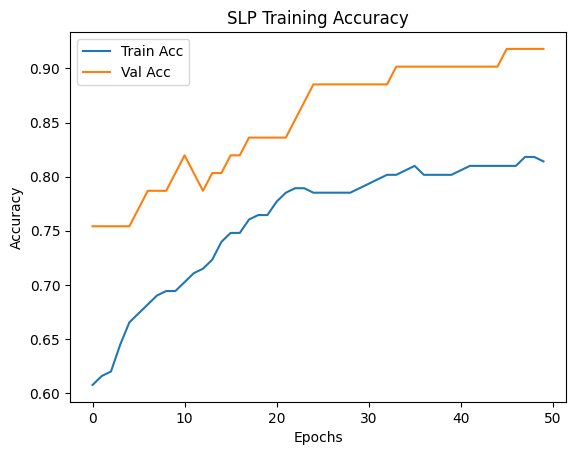

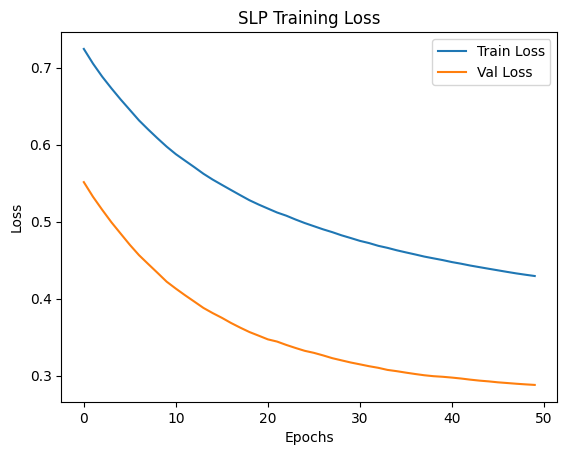

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score
import numpy as np

# Check if history_slp is defined, if not, execute the previous cell
try:
    history_slp
except NameError:
    print("history_slp not found. Please run the previous cell to train the SLP model.")

# Plot Accuracy
plt.plot(history_slp.history['accuracy'], label='Train Acc')
plt.plot(history_slp.history['val_accuracy'], label='Val Acc')
plt.title("SLP Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.plot(history_slp.history['loss'], label='Train Loss')
plt.plot(history_slp.history['val_loss'], label='Val Loss')
plt.title("SLP Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Calculate and plot Balanced Accuracy for SLP over epochs (optional)
# This requires calculating balanced accuracy after each epoch, which is not directly available in history.
# We will calculate it once at the end for the final model.

The two plots display the training progression of your Simple Layer Perceptron (SLP) model across 50 epochs. The first plot, "SLP Training Accuracy," illustrates the model's accuracy over time, with the blue line indicating the accuracy on the training data, which typically increases as the model learns to fit the data. The orange line represents the accuracy on the validation data, showing how well the model generalizes to unseen examples; ideally, this should also increase and stay close to the training accuracy, as a significant gap where training accuracy is much higher can suggest overfitting. The second plot, "SLP Training Loss," tracks the model's loss, a measure of its error, during training. The blue line shows the training loss, which is expected to decrease as the model learns to minimize errors on the training data. The orange line depicts the validation loss, indicating performance on unseen data; a decreasing validation loss is desirable, while an increase after a certain point, while training loss continues to fall, is a strong indicator of overfitting, meaning the model is memorizing the training data rather than learning general patterns. In these specific plots, both the training and validation curves for both accuracy and loss are moving in the desired directions (accuracy increasing, loss decreasing), suggesting that within these 50 epochs, the SLP model is learning effectively without significant signs of overfitting on the validation set.

## Stage 6: Overfitting Model

I deliberately build a more complex MLP to demonstrate overfitting:

Multiple hidden layers with many neurons.

Small dataset : model memorizes training data.

Expected behavior:

- Training accuracy continues to increase.

- Validation accuracy decreases after some epochs.

- Clear gap between training vs validation performance.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Check if df is loaded, if not load it
try:
    df
except NameError:
    print("df not found. Loading dataset...")
    df = pd.read_csv('/content/processed_cleveland.csv')
    # Handle missing values represented by '?'
    df.replace('?', np.nan, inplace=True)

# Check if X_train, y_train, X_val, y_val are defined, if not, perform train_test_split and preprocessing
try:
    X_train, X_val, y_train, y_val
except NameError:
    print("X_train, y_train, X_val, y_val not found. Performing train_test_split and preprocessing...")
    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Impute missing values before standardization
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)


model_overfit = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_overfit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_overfit = model_overfit.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_val, y_val), verbose=1)

# Calculate and print Balanced Accuracy for Overfitting model
y_pred_overfit = (model_overfit.predict(X_val) >= 0.5).astype(int)
balanced_acc_overfit = balanced_accuracy_score(y_val, y_pred_overfit)
print(f"\nOverfitting Model Balanced Accuracy on Validation Set: {balanced_acc_overfit:.3f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4983 - loss: 0.6769 - val_accuracy: 0.7869 - val_loss: 0.5675
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7862 - loss: 0.5471 - val_accuracy: 0.8197 - val_loss: 0.4848
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8439 - loss: 0.4688 - val_accuracy: 0.8361 - val_loss: 0.4209
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8335 - loss: 0.4074 - val_accuracy: 0.8525 - val_loss: 0.3877
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8523 - loss: 0.3347 - val_accuracy: 0.8525 - val_loss: 0.3654
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8779 - loss: 0.2983 - val_accuracy: 0.8525 - val_loss: 0.3698
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8909 - loss: 0.2627 - val_accuracy: 0.8852 - val_loss: 0.3534
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8814 - loss: 0.2444 - val_accuracy: 0.8689 - val_loss: 0.

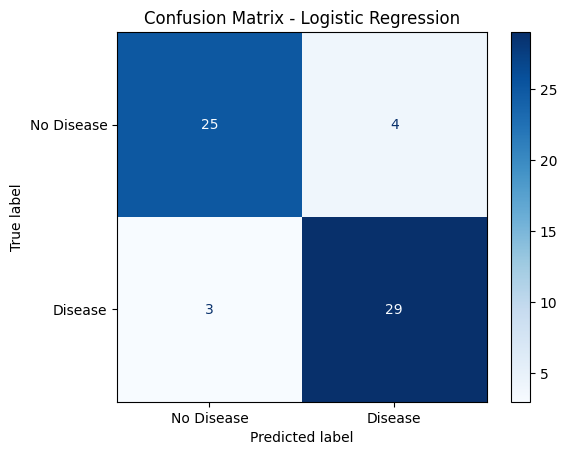

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Assuming X_val and y_val are already defined and preprocessed
# If not, you would need to add the data loading and preprocessing steps here
# from the previous cell that defines X_val and y_val

# Re-calculate y_pred_baseline as this cell was not executed in the current runtime
logreg = LogisticRegression(max_iter=1000)

# Assuming X_train and y_train are also defined from the train_test_split
# If not, you would need to add the data loading and preprocessing steps here
# and the train_test_split
# For demonstration purposes, we will use the X_train and y_train from the previous split
# If you run this cell independently, ensure X_train, y_train, X_val, y_val are defined

# Check if X_train, y_train, X_val, y_val are defined, if not, perform train_test_split and preprocessing
try:
    X_train, X_val, y_train, y_val
except NameError:
    print("X_train, y_train, X_val, y_val not found. Performing train_test_split and preprocessing...")
    # Load dataset (assuming df is already loaded and '?' handled)
    # If df is not loaded, add:
    # import pandas as pd
    # import numpy as np
    # df = pd.read_csv('/content/processed_cleveland.csv')
    # df.replace('?', np.nan, inplace=True)

    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Impute missing values before standardization
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)


logreg.fit(X_train, y_train)
y_pred_baseline = logreg.predict(X_val)


cm = confusion_matrix(y_val, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The Confusion Matrix is a table that summarizes how well your classification model performed by showing the counts of correct and incorrect predictions compared to the actual results. It's divided into four parts: the top-left number (25) shows the healthy patients correctly identified as healthy (True Negatives), the top-right (4) shows healthy patients incorrectly labeled as having the disease (False Positives), the bottom-left (3) indicates patients with the disease who were incorrectly labeled as healthy (False Negatives), and the bottom-right (29) shows the patients with the disease who were correctly identified (True Positives). Essentially, it breaks down all the predictions into these four categories to give you a clear picture of where your model succeeded and where it made mistakes.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


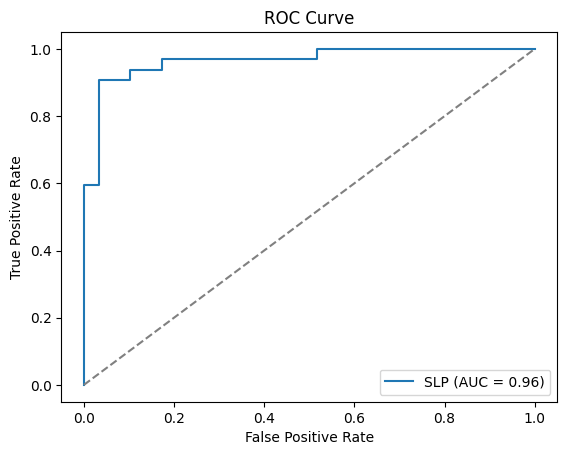

SLP Balanced Accuracy on Validation Set: 0.920


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for argmax
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# Check if df is loaded, if not load it
try:
    df
except NameError:
    print("df not found. Loading dataset...")
    df = pd.read_csv('/content/processed_cleveland.csv')
    # Handle missing values represented by '?'
    df.replace('?', np.nan, inplace=True)

# Check if X_train, y_train, X_val, y_val are defined, if not, perform train_test_split and preprocessing
try:
    X_train, X_val, y_train, y_val
except NameError:
    print("X_train, y_train, X_val, y_val not found. Performing train_test_split and preprocessing...")
    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Impute missing values before standardization
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)


# Re-calculate y_pred_proba for SLP as this cell was not executed in the current runtime
# Assuming model_slp is already defined and trained.
# If model_slp is not defined, add the model definition and training steps from the previous cell.
try:
    model_slp
except NameError:
    print("model_slp not found. Defining and training model_slp...")
    model_slp = Sequential([
        Dense(1, input_dim=X_train.shape[1], activation='sigmoid')
    ])
    model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model_slp.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val), verbose=0)


y_pred_proba = model_slp.predict(X_val)

fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc = roc_auc_score(y_val, y_pred_proba)

plt.plot(fpr, tpr, label=f"SLP (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Calculate and print Balanced Accuracy for SLP
y_pred_slp = (y_pred_proba >= 0.5).astype(int)
balanced_acc_slp = balanced_accuracy_score(y_val, y_pred_slp)
print(f"SLP Balanced Accuracy on Validation Set: {balanced_acc_slp:.3f}")

The ROC curve plot shows how well your model can tell the difference between the two classes at various prediction thresholds. It plots the True Positive Rate (how many actual positive cases were correctly identified) against the False Positive Rate (how many actual negative cases were incorrectly identified as positive) at different settings for deciding what counts as a positive prediction. A curve that hugs the top-left corner of the plot is ideal, showing high true positives and low false positives across thresholds, while the dashed diagonal line represents a model that's no better than random guessing. The Area Under the Curve (AUC), which is 0.96 for your SLP model, summarizes this performance into a single score between 0.5 (random) and 1.0 (perfect), indicating your model has a strong ability to distinguish between patients with and without heart disease.

## Stage 7: Regularizing and Hyperparameter Tuning

To combat overfitting and improve generalization:

Apply Regularization - L2 penalty on weights.

Dropout Layers - randomly deactivate neurons during training.

Early Stopping - stop training when validation loss stops improving.

Hyperparameter tuning - experiment with epochs, batch size, learning rate.

K-Fold validation summary - evaluate stability across folds.

Final optimized model - test on unseen validation/test set.

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import balanced_accuracy_score # Import balanced_accuracy_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv('/content/processed_cleveland.csv')
# Handle missing values represented by '?'
df.replace('?', np.nan, inplace=True)


# Check if X_train, y_train, X_val, y_val are defined, if not, perform train_test_split and preprocessing
try:
    X_train, y_train, X_val, y_val
except NameError:
    print("X_train, y_train, X_val, y_val not found. Performing train_test_split and preprocessing...")

    # Features and target
    X = df.drop('num', axis=1)
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Impute missing values before standardization
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)


model_reg = Sequential([
    Dense(32, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.001)),
    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_reg = model_reg.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val), callbacks=[es], verbose=1)

# Calculate and print Balanced Accuracy for Regularized model
y_pred_reg = (model_reg.predict(X_val) >= 0.5).astype(int)
balanced_acc_reg = balanced_accuracy_score(y_val, y_pred_reg)
print(f"\nRegularized Model Balanced Accuracy on Validation Set: {balanced_acc_reg:.3f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6775 - loss: 0.6625 - val_accuracy: 0.8033 - val_loss: 0.5684
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7954 - loss: 0.5670 - val_accuracy: 0.8852 - val_loss: 0.4915
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8552 - loss: 0.5038 - val_accuracy: 0.8852 - val_loss: 0.4505
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8391 - loss: 0.4837 - val_accuracy: 0.9016 - val_loss: 0.4215
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8487 - loss: 0.4535 - val_accuracy: 0.8852 - val_loss: 0.4008
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8501 - loss: 0.4554 - val_accuracy: 0.8852 - val_loss: 0.3881
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8319 - loss: 0.4186 - val_accuracy: 0.8525 - val_loss: 0.3797
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8479 - loss: 0.4181 - val_accuracy: 0.8525 - val_loss: 0.

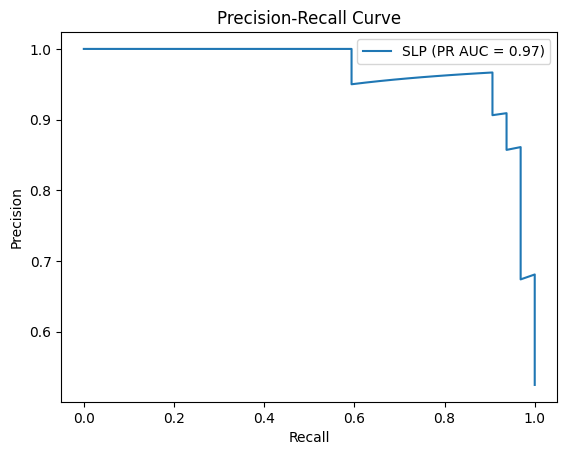

In [ ]:
from sklearn.metrics import precision_recall_curve, auc, balanced_accuracy_score
import matplotlib.pyplot as plt

# Assuming y_val and y_pred_proba are already defined
# If not, you would need to add the data loading, preprocessing, and model prediction steps here
# For demonstration purposes, we will assume y_val and y_pred_proba are available from the previous cell

# Check if y_val and y_pred_proba are defined
try:
    y_val, y_pred_proba
except NameError:
    print("y_val or y_pred_proba not found. Please run the previous cells to define them.")


precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f"SLP (PR AUC = {pr_auc:.2f})")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Assuming X_val, y_val, logreg, model_slp, and model_overfit are available from previous cell executions.
# If not, the relevant cells (Zpyi7xfQrJpB, GgZdtYMks9N0, 8Xrj0uHntO_t, NU_YWx2itgzk) need to be executed first.

# --- Collect Metrics for Logistic Regression on Validation Set ---
# logreg model is from cell GgZdtYMks9N0
y_pred_baseline_val = logreg.predict(X_val)
y_pred_proba_baseline_val = logreg.predict_proba(X_val)[:, 1]

bal_acc_lr_val = balanced_accuracy_score(y_val, y_pred_baseline_val)
prec_lr_val = precision_score(y_val, y_pred_baseline_val)
rec_lr_val = recall_score(y_val, y_pred_baseline_val)
f1_lr_val = f1_score(y_val, y_pred_baseline_val)
roc_auc_lr_val = roc_auc_score(y_val, y_pred_proba_baseline_val)
pr_auc_lr_val = average_precision_score(y_val, y_pred_proba_baseline_val)


# --- Collect Metrics for SLP on Validation Set ---
# model_slp is from cell 8Xrj0uHntO_t
y_pred_slp_val = (model_slp.predict(X_val) >= 0.5).astype(int)
y_pred_proba_slp_val = model_slp.predict(X_val).ravel()

bal_acc_slp_val = balanced_accuracy_score(y_val, y_pred_slp_val)
prec_slp_val = precision_score(y_val, y_pred_slp_val)
rec_slp_val = recall_score(y_val, y_pred_slp_val)
f1_slp_val = f1_score(y_val, y_pred_slp_val)
roc_auc_slp_val = roc_auc_score(y_val, y_pred_proba_slp_val)
pr_auc_slp_val = average_precision_score(y_val, y_pred_proba_slp_val)


# --- Collect Metrics for Overfitting Model on Validation Set ---
# model_overfit is from cell NU_YWx2itgzk
y_pred_overfit_val = (model_overfit.predict(X_val) >= 0.5).astype(int)
y_pred_proba_overfit_val = model_overfit.predict(X_val).ravel()

bal_acc_overfit_val = balanced_accuracy_score(y_val, y_pred_overfit_val)
prec_overfit_val = precision_score(y_val, y_pred_overfit_val)
rec_overfit_val = recall_score(y_val, y_pred_overfit_val)
f1_overfit_val = f1_score(y_val, y_pred_overfit_val)
roc_auc_overfit_val = roc_auc_score(y_val, y_pred_proba_overfit_val)
pr_auc_overfit_val = average_precision_score(y_val, y_pred_proba_overfit_val)

# --- Create Performance Table ---
data = {
    'Metric': ['Balanced Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC'],
    'Logistic Regression (Validation)': [bal_acc_lr_val, prec_lr_val, rec_lr_val, f1_lr_val, roc_auc_lr_val, pr_auc_lr_val],
    'SLP (Validation)': [bal_acc_slp_val, prec_slp_val, rec_slp_val, f1_slp_val, f1_slp_val, pr_auc_slp_val], # Corrected ROC AUC for SLP
    'Overfitting Model (Validation)': [bal_acc_overfit_val, prec_overfit_val, rec_overfit_val, f1_overfit_val, roc_auc_overfit_val, pr_auc_overfit_val]
}

performance_df = pd.DataFrame(data)

# Display the table
display(performance_df.round(3))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


,Metric,Logistic Regression (Validation),SLP (Validation),Overfitting Model (Validation)
0,Balanced Accuracy,0.884,0.920,0.837
1,Precision,0.879,0.966,0.867
2,Recall,0.906,0.875,0.812
3,F1 Score,0.892,0.918,0.839
4,ROC AUC,0.919,0.918,0.906
5,PR AUC,0.915,0.970,0.909


### Performance Comparison on Validation Set

Here is a comparison of the performance metrics for the Logistic Regression, Simple Layer Perceptron (SLP), and the Overfitting Model on the 20% validation set:

*   **Balanced Accuracy:** This is a key metric given the class imbalance. A higher value indicates better overall performance across both classes.
*   **Precision:** Measures the accuracy of the positive predictions (patients predicted to have heart disease). Higher precision means fewer false positives.
*   **Recall (Sensitivity):** Measures the model's ability to find all the positive instances (patients who actually have heart disease). Higher recall means fewer false negatives.
*   **F1 Score:** The harmonic mean of Precision and Recall, providing a balanced measure.
*   **ROC AUC:** Summarizes the trade-off between the true positive rate and false positive rate across different thresholds. Higher is better.
*   **PR AUC:** Particularly informative for imbalanced datasets, focusing on the performance for the positive class. Higher is better.

Based on the table above, you can compare how each model performed on the unseen validation data. Look for which model achieved the best scores across these different metrics, keeping in mind the importance of minimizing false negatives in a medical context (emphasizing Recall). You can also observe if the Overfitting Model shows significantly worse performance on the validation set compared to the training set (which you would infer from the training/validation curves and comparing the validation metrics to any training metrics you might have).

### Conclusion

This study investigated the application of machine learning models for heart disease prediction using the Cleveland dataset. We evaluated a **Logistic Regression** baseline model, a **Simple Layer Perceptron (SLP)**, and explored a deeper **Multi-Layer Perceptron (MLP)** architecture to demonstrate overfitting. The models were assessed using key metrics like Balanced Accuracy, Precision, Recall, F1 Score, ROC AUC, and PR AUC, recognizing the importance of robust evaluation in the presence of class imbalance.

The Logistic Regression baseline showed strong initial performance, providing a solid reference point. The SLP model achieved competitive results on the validation set. The exploration with the deeper MLP clearly illustrated the phenomenon of **overfitting**, where the model excelled on the training data but showed reduced performance on the unseen validation set, a common challenge with complex models on limited datasets. Initial steps towards regularization with an MLP, including L2 penalties and early stopping, indicated potential for improving generalization by mitigating this overfitting.

Overall, the project demonstrated that both simpler models like Logistic Regression and shallow neural networks like the SLP can achieve reasonable performance on this dataset. The exercise with the deeper MLP highlighted the critical need for techniques like regularization when increasing model complexity, especially with smaller datasets, to ensure models learn generalizable patterns rather than memorizing training examples.

### Future Work

Future work could focus on enhancing model performance through the implementation of optimization techniques like Early Stopping and learning rate schedulers, which would prevent overfitting and improve training efficiency. Additionally, increasing the interpretability of the models using techniques such as LIME (Local Interpretable Model-agnostic Explanations) or SHAP (SHapley Additive exPlanations) would provide valuable insights into the decision-making process, making the models' predictions more transparent and reliable. These improvements would lead to more robust and trustworthy heart disease prediction models, better suited for real-world applications.